In [20]:
import sys, pymc, pytensor
print(sys.executable)
print("PyMC", pymc.__version__)
print("PyTensor compiler", pytensor.config.cxx)

/opt/anaconda3/envs/pymc3.11/bin/python
PyMC 5.26.1
PyTensor compiler /opt/anaconda3/envs/pymc3.11/bin/clang++


In [21]:
import numpy as np, pymc as pm, pytensor, arviz as az, sklearn


print("NumPy:", np.__version__)
print("PyMC:", pm.__version__)
print("PyTensor:", pytensor.__version__)
print("ArviZ:", az.__version__)


NumPy: 2.3.4
PyMC: 5.26.1
PyTensor: 2.35.1
ArviZ: 0.22.0


In [22]:
import pymc as pm
with pm.Model():
    x = pm.Normal("x", 0, 1)
    y = pm.Normal("y", x, 1)
    trace = pm.sample(500, tune=500, cores=1, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [x, y]


/opt/anaconda3/envs/pymc3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [23]:
# Load data from transforms_and_modelling notebook
import pickle
import numpy as np
import pandas as pd

X_trs = pd.DataFrame(np.load('../data/processed/X_trs.npy'))
X_vas = pd.DataFrame(np.load('../data/processed/X_vas.npy'))
y_tr = np.load('../data/processed/y_tr.npy')
y_va = np.load('../data/processed/y_va.npy')

with open('../data/processed/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../data/processed/cont_feats.pkl', 'rb') as f:
    cont_feats = pickle.load(f)

with open('../data/processed/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

X_trs.columns = feature_names
X_vas.columns = feature_names

print("Data loaded for PyMC notebook")
print(f"X_trs shape: {X_trs.shape}, y_tr shape: {y_tr.shape}")
print(f"X_vas shape: {X_vas.shape}, y_va shape: {y_va.shape}")


Data loaded for PyMC notebook
X_trs shape: (9288, 66), y_tr shape: (9288,)
X_vas shape: (2322, 66), y_va shape: (2322,)


In [24]:
X_trs

,ilr_counts_z1,ilr_counts_z2,ilr_durs_z1,ilr_durs_z2,PageValues,BounceRates,ExitRates,Weekend,SpecialDay,VisitorType_New_Visitor,...,TrafficType_18,TrafficType_19,TrafficType_20,OperatingSystems_1,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8
0,1.079746,-0.649364,1.032976,-0.648011,-0.327708,-0.526528,0.548821,0.0,0.6,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.633643,-0.450270,-1.394547,-0.177699,-0.105550,-0.313574,-0.351355,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.079746,-0.649364,1.032976,-0.648011,-0.327708,-0.526528,-0.127026,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.256560,1.126848,-0.111746,0.901111,-0.327708,-0.526528,-0.636105,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.079746,-0.649364,1.032976,-0.648011,-0.327708,-0.526528,-0.162135,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9283,-1.585549,-0.493487,-1.439665,-0.221688,-0.327708,0.169227,-0.149588,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9284,-0.489874,1.352944,-0.277192,1.112010,-0.327708,-0.526528,0.336142,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9285,-0.319003,1.197066,-0.496376,1.342057,-0.327708,-0.526528,-0.695351,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9286,1.079746,-0.649364,1.032976,-0.648011,-0.327708,-0.412065,-0.229280,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Prepare data for PyMC
# Convert training design matrix to float64 NumPy array to avoid dtype surprises
X_array = X_trs.to_numpy(dtype=np.float64)
# Cast labels to int32 (PyMC expects ints for Bernoulli observed values)
y_array = y_tr.astype(np.int32)

print(f"Feature matrix shape: {X_array.shape}")
print(f"Target shape: {y_array.shape}")
print(f"Number of features: {X_array.shape[1]}")
print(f"X_array dtype: {X_array.dtype}, y_array dtype: {y_array.dtype}")

# Define Bayesian logistic regression model in PyMC
with pm.Model() as shopper_model:
    # Gaussian priors on coefficients (including intercept)
    beta = pm.Normal("beta", mu=0, sigma=2, shape=X_array.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    # Linear predictor: X @ beta + intercept
    logits = intercept + pm.math.dot(X_array, beta)

    # Bernoulli likelihood for conversion outcome
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y_array)

    # Hamiltonian Monte Carlo via NUTS sampler
    trace = pm.sample(
        draws=2000,       # posterior draws after tuning
        tune=2000,        # warmup iterations for step-size adaptation
        target_accept=0.9,# more conservative step-size to reduce divergences
        random_seed=42,
        cores=4,          # single core to avoid multiprocessing issues
        progressbar=True
    )



Initializing NUTS using jitter+adapt_diag...


Feature matrix shape: (9288, 66)
Target shape: (9288,)
Number of features: 66
X_array dtype: float64, y_array dtype: int32


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


/opt/anaconda3/envs/pymc3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 48 seconds.


In [26]:

summary = az.summary(trace, var_names=["beta", "intercept"])
summary["feature"] = ["intercept"] + list(X_trs.columns)
summary[["feature","mean","sd","hdi_3%","hdi_97%"]].head(10)


,feature,mean,sd,hdi_3%,hdi_97%
beta[0],intercept,-0.535,0.128,-0.772,-0.289
beta[1],ilr_counts_z1,0.070,0.101,-0.118,0.257
beta[2],ilr_counts_z2,0.321,0.128,0.081,0.567
beta[3],ilr_durs_z1,-0.115,0.099,-0.311,0.057
beta[4],ilr_durs_z2,1.553,0.052,1.456,1.649
beta[5],PageValues,-0.022,0.096,-0.205,0.155
beta[6],BounceRates,-0.535,0.083,-0.693,-0.379
beta[7],ExitRates,0.133,0.080,-0.022,0.283
beta[8],Weekend,0.084,0.264,-0.402,0.591
beta[9],SpecialDay,0.118,0.099,-0.062,0.307


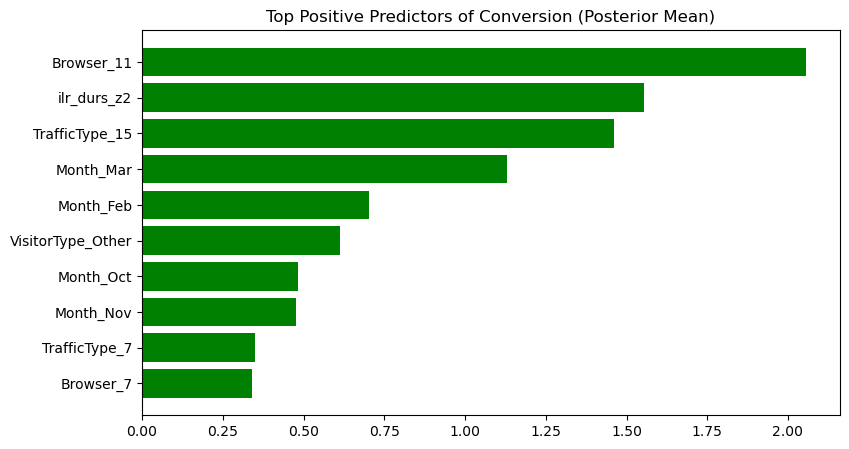

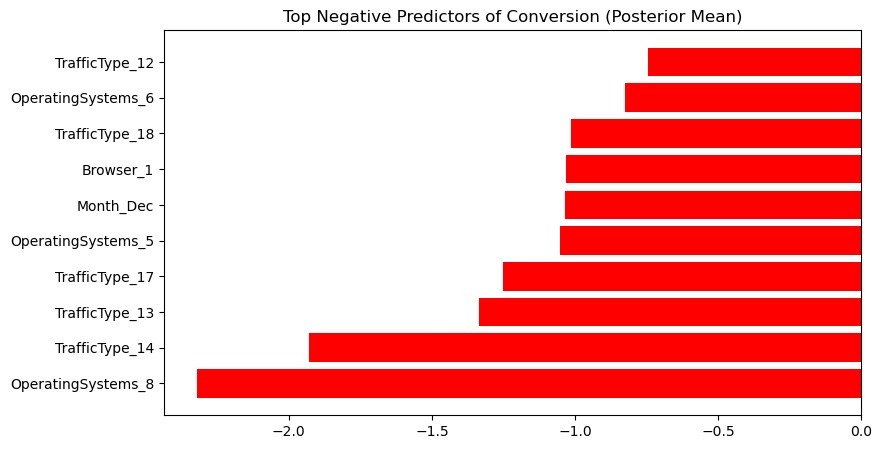

In [27]:
import matplotlib.pyplot as plt
summary_beta = summary.loc[summary["feature"]!="intercept"]
summary_sorted = summary_beta.sort_values("mean")

top_pos = summary_sorted.tail(10)
top_neg = summary_sorted.head(10)

plt.figure(figsize=(9,5))
plt.barh(top_pos["feature"], top_pos["mean"], color="green")
plt.title("Top Positive Predictors of Conversion (Posterior Mean)")
plt.show()

plt.figure(figsize=(9,5))
plt.barh(top_neg["feature"], top_neg["mean"], color="red")
plt.title("Top Negative Predictors of Conversion (Posterior Mean)")
plt.show()


<Axes: title={'center': 'intercept'}>

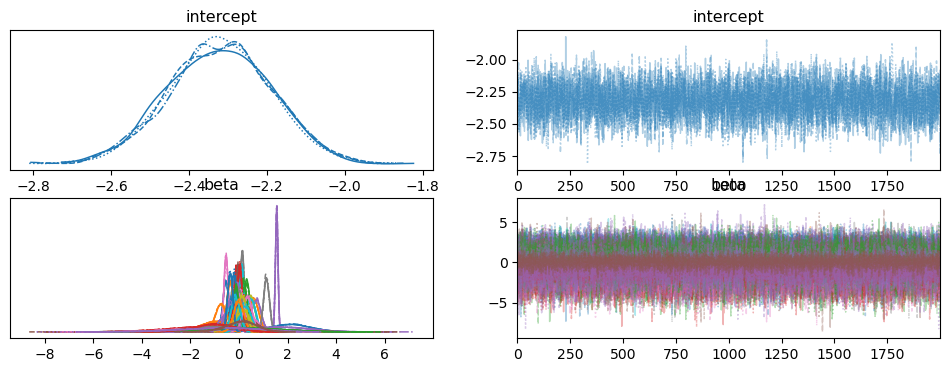

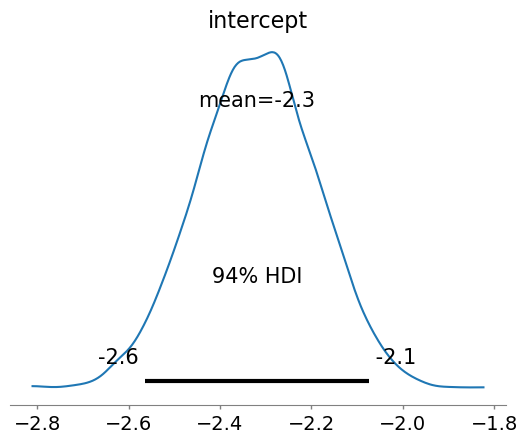

In [28]:
az.plot_trace(trace, var_names=["intercept", "beta"])
az.plot_posterior(trace, var_names=["intercept"])


In [31]:
# Save PyMC model results for rationality estimation
import pickle
import os

os.makedirs('../data/processed', exist_ok=True)

# Extract posterior means and summaries
beta_posterior_mean = trace.posterior["beta"].mean(dim=["chain", "draw"]).values
intercept_posterior_mean = trace.posterior["intercept"].mean(dim=["chain", "draw"]).values
beta_posterior_std = trace.posterior["beta"].std(dim=["chain", "draw"]).values
intercept_posterior_std = trace.posterior["intercept"].std(dim=["chain", "draw"]).values

# Extract ALL actual posterior samples (all draws from all chains)
# Shape: (n_chains * n_draws, n_features) for beta, (n_chains * n_draws,) for intercept
beta_all_samples = trace.posterior["beta"].values.reshape(-1, trace.posterior["beta"].shape[-1])
intercept_all_samples = trace.posterior["intercept"].values.reshape(-1)

# Save trace (full posterior samples)
with open('../data/processed/pymc_trace.pkl', 'wb') as f:
    pickle.dump(trace, f)

# Save summary statistics
with open('../data/processed/pymc_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

# Save posterior means, stds, AND all actual samples for easy access
pymc_results = {
    'beta_mean': beta_posterior_mean,
    'beta_std': beta_posterior_std,
    'beta_all_samples': beta_all_samples,  # All actual beta values
    'intercept_mean': intercept_posterior_mean,
    'intercept_std': intercept_posterior_std,
    'intercept_all_samples': intercept_all_samples,  # All actual intercept values
    'feature_names': list(X_trs.columns),
    'n_features': X_array.shape[1],
    'n_samples': len(y_array),
    'n_chains': trace.posterior.sizes['chain'],  # Use .sizes instead of .dims
    'n_draws': trace.posterior.sizes['draw']     # Use .sizes instead of .dims
}

with open('../data/processed/pymc_posterior_estimates.pkl', 'wb') as f:
    pickle.dump(pymc_results, f)

# Save model for potential future use (optional)
# Note: PyMC models may contain non-pickleable objects, so we wrap in try-except
model_saved = False
try:
    with open('../data/processed/pymc_model.pkl', 'wb') as f:
        pickle.dump(shopper_model, f)
    model_saved = True
except Exception as e:
    print(f"Warning: Could not save model object: {type(e).__name__}: {e}")
    print("  (This is okay - you can recreate the model using saved parameters if needed)")

print("\nPyMC results saved successfully!")
print(f"Beta posterior mean shape: {beta_posterior_mean.shape}")
print(f"Beta ALL samples shape: {beta_all_samples.shape} (all draws from all chains)")
print(f"Intercept ALL samples shape: {intercept_all_samples.shape}")
print(f"Intercept posterior mean: {intercept_posterior_mean:.4f}")
print(f"Beta posterior mean range: [{beta_posterior_mean.min():.4f}, {beta_posterior_mean.max():.4f}]")
print(f"\nSaved files:")
print("  - pymc_trace.pkl (full trace with all posterior samples)")
print("  - pymc_summary.pkl (ArviZ summary statistics)")
print("  - pymc_posterior_estimates.pkl (posterior means/stds + ALL actual samples + metadata)")
if model_saved:
    print("  - pymc_model.pkl (PyMC model object)")



  (This is okay - you can recreate the model using saved parameters if needed)

PyMC results saved successfully!
Beta posterior mean shape: (66,)
Beta ALL samples shape: (8000, 66) (all draws from all chains)
Intercept ALL samples shape: (8000,)
Intercept posterior mean: -2.3202
Beta posterior mean range: [-1.9301, 2.0573]

Saved files:
  - pymc_trace.pkl (full trace with all posterior samples)
  - pymc_summary.pkl (ArviZ summary statistics)
  - pymc_posterior_estimates.pkl (posterior means/stds + ALL actual samples + metadata)
